In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftshift
from scipy import special

In [2]:
wp = 0.15*np.pi
ws = 0.2*np.pi
T = 1
Fs = 1/T
OmegaP = (2/T)*np.tan(wp/2)
OmegaS = (2/T)*np.tan(ws/2)
wmax=np.pi
Rp = 1
As = 40
ep = np.sqrt(10**(Rp/10)-1)
AA = 10**(As/20)
Omegac = OmegaP
k = OmegaP/OmegaS
k1 = ep/np.sqrt(AA**2-1)

In [3]:
capk = special.ellipk([k**2,1-k**2])
capk1 = special.ellipk([(k1**2),1-(k1**2)])

N = np.ceil(capk[0]*capk1[1]/(capk[1]*capk1[0]))
[z,p,k] = signal.ellipap(N,Rp,As)

a = np.real(np.poly(p))
aNn = a[int(N)]
p2 = p*Omegac
a2 = np.real(np.poly(p2))
aNu = a2[int(N)]
b = np.real(np.poly(z))

M = len(b);
bNn = b[int(M-1)]
z2 = z*Omegac
b2 = np.real(np.poly(z2))
bNu = b2[int(M-1)]
k = k*(aNu*bNn)/(aNn*bNu)
bt = k*b2
at=a2

Text(0, 0.5, 'Phase')

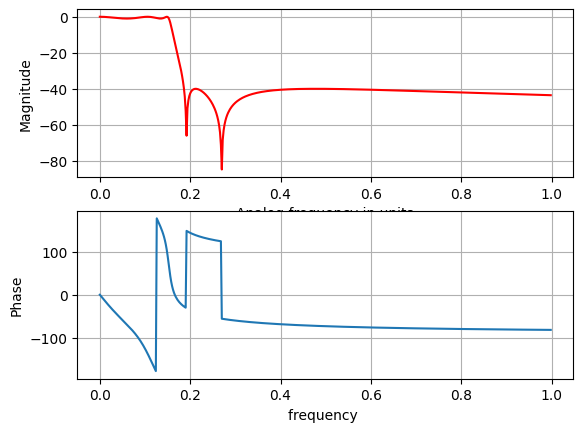

In [4]:

w = np.arange(0,500)*wmax/500
_ , h = signal.freqs(bt,at,w)
mag = 20 * np.log10(np.abs(h))
phase = np.angle(h)
phasedeg = phase*180/np.pi


plt.figure()
plt.subplot(211)
plt.plot(w/np.pi,mag,color='red')
plt.grid(True)
plt.xlabel('Analog frequency in units')
plt.ylabel('Magnitude')


plt.subplot(212)
plt.plot(w/np.pi,phasedeg)
plt.grid(True)
plt.xlabel('frequency ')
plt.ylabel('Phase')

In [5]:
[b1,a1] = signal.bilinear(bt,at,Fs)
def zmapping (bZ,aZ,Nz,Dz):
    bNzord = (len(bZ)-1)*(len(Nz)-1)
    aDzord = (len(aZ)-1)*(len(Dz)-1)
    bzord = len(bZ)-1
    azord = len(aZ)-1
    bz = np.zeros(bNzord+1)
    for k in range(bzord+1):
        pln = [1]
        for l in range(k):
            pln = np.convolve(pln,Nz,mode='full')
        pld = [1]
        for l in range(bzord-k):
            pld = np.convolve(pld,Dz,mode='full')
        bz = bz+bZ[k]*np.convolve(pln,pld,mode='full')
    az = np.zeros(aDzord+1)
    for k in range(azord+1):
        pln = [1]
        for l in range(k):
            pln = np.convolve(pln,Nz,mode='full')
        pld = [1]
        for l in range(azord-k):
            pld = np.convolve(pld,Dz,mode='full')
        az = az+aZ[k]*np.convolve(pln,pld,mode='full')
    return bz,az

Text(0, 0.5, 'Phase (degrees)')

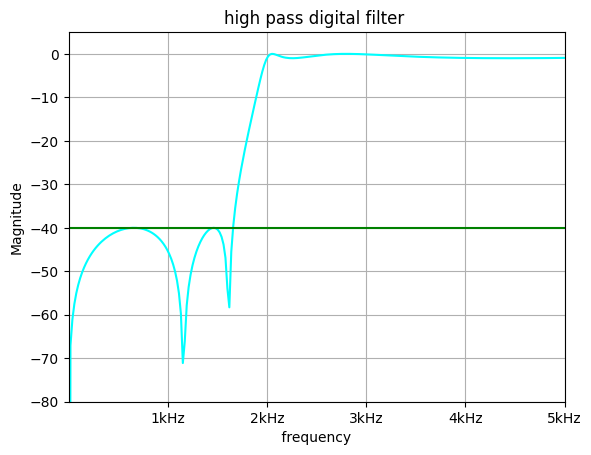

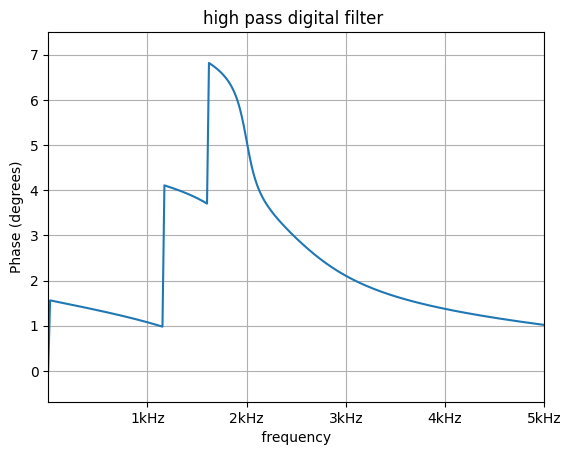

In [6]:
wphp = 0.2*np.pi
alpha = -(np.cos((wp+wphp)/2))/(np.cos((wp-wphp)/2))
Nz = [-alpha,-1]
Dz = [1,alpha]
[bhp,ahp] = zmapping(b1,a1,Nz,Dz)
fs=10000
w, h = signal.freqz(bhp,ahp)
plt.figure()
plt.plot(w/np.pi*fs, 20 * np.log10(np.abs(h)),color='cyan')
plt.grid(True)
plt.xticks([1000,2000,3000,4000,5000], ['1kHz', '2kHz', '3kHz', '4kHz','5kHz'])
plt.title('high pass digital filter ')
plt.xlim([0,5000])
plt.xlabel(' frequency ')
plt.ylabel('Magnitude')
plt.ylim([-80,5])
plt.margins(0, 0.1)
plt.axhline(-40, color='green') # rs
plt.figure()
angles = np.unwrap(np.angle(h))
plt.plot(w/np.pi*10000, angles)
plt.xticks([1000,2000,3000,4000,5000], ['1kHz', '2kHz', '3kHz', '4kHz','5kHz'])
plt.xlim([0,5000])
plt.grid(True)
plt.margins(0, 0.1)
plt.title('high pass digital filter ')
plt.xlabel(' frequency ')
plt.ylabel('Phase (degrees)')

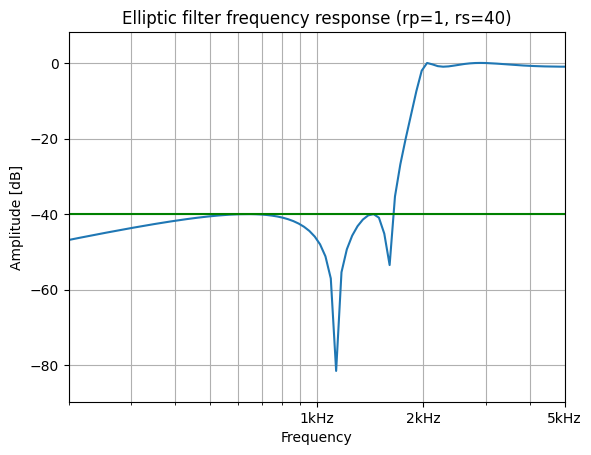

In [7]:
#easiest way to generate this filter
N,Wn = signal.ellipord(0.2,0.15,Rp,As,True)
b, a = signal.ellip(N, 1, 40, Wn, 'high', analog=True)
w, h = signal.freqs(b, a)
plt.semilogx(w*10000, 20 * np.log10(abs(h)))
plt.xlim([200,5000])
plt.xticks([1000,2000,5000], ['1kHz', '2kHz','5kHz'])
plt.title('Elliptic filter frequency response (rp=1, rs=40)')
plt.xlabel('Frequency' )
plt.ylabel('Amplitude [dB]')
plt.margins(0, 0.1)
plt.grid(which='both', axis='both')
plt.axhline(-40, color='green') # rs

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:3413: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'magnitude')

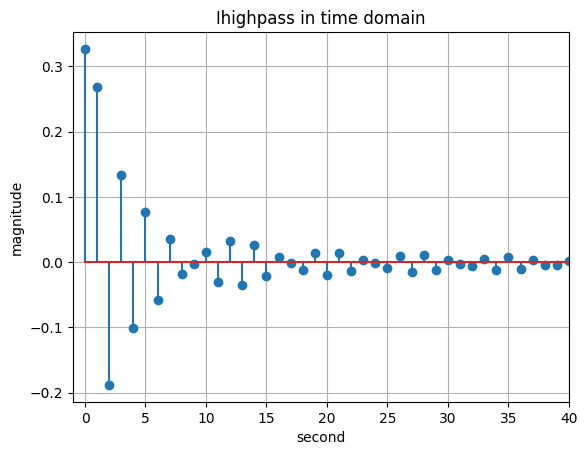

In [8]:
import scipy
time=scipy.fft.ifft(h)
plt.stem(time)
plt.xlim([-1,40])
plt.grid(True)
plt.title('اhighpass in time domain')
plt.xlabel('second')
plt.ylabel('magnitude')